In [9]:
import sys
import os
from pathlib import Path 
import yaml

sys.path.append(str(Path.cwd().parent))

from src.utils.reproducibility import set_global_seed

import pandas as pd
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_pinball_loss
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
import mlflow.lightgbm

In [10]:
params_path = Path("params.yaml")
if not params_path.exists():
    params_path = Path("../params.yaml")

with open(params_path, "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

seed = int(params["global"]["seed"])
set_global_seed(seed)

print(f"Global seed set to: {seed}")

Global seed set to: 42


In [12]:
# Load processed data
df_data = pd.read_parquet("../data/validated/validated_data.parquet")
df_data = df_data.sort_values("timestamp").reset_index(drop=True)
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 20 columns):
 #   Column                                                             Non-Null Count  Dtype              
---  ------                                                             --------------  -----              
 0   timestamp                                                          17544 non-null  datetime64[ns, UTC]
 1   end_timestamp                                                      17544 non-null  datetime64[ns, UTC]
 2   grid load [MWh] Calculated resolutions                             17544 non-null  float64            
 3   Grid load incl. hydro pumped storage [MWh] Calculated resolutions  17544 non-null  object             
 4   Hydro pumped storage [MWh] Calculated resolutions_x                17544 non-null  object             
 5   residual_load_mwh                                                  17544 non-null  float64            
 6   Biomass [MWh] Calculat

## Baseline model strategy

Our final goal is to build a **probabilistic day-ahead residual load forecast** that predicts **P10, P50, and P90** for each of the next 24 hours.

Before moving to probabilistic models, we first run a small set of **simple point-forecast baselines**.

We do this for a practical reason: it helps us quickly check that the data pipeline, lag features, train/test split, and overall forecasting setup are correct. It also tells us whether the target can already be explained reasonably well by simple daily and weekly patterns. This stage is **not** used to choose the final model for the project. It is a short sanity-check and benchmarking stage.

### Baseline signals
For day-ahead hourly residual load forecasting, the first two signals to test are:
- **same hour yesterday** (`lag_24`)
- **same hour last week** (`lag_168`)
These are used because they capture the two strongest simple structures in hourly electricity-style data:
- **daily repetition**
- **weekly repetition**
They are also easy to explain and available at forecast time.

### Point-forecast baselines
#### 1. Naive-24
Forecast = residual load from the same hour yesterday.
This is the simplest daily-pattern benchmark.

#### 2. Naive-168
Forecast = residual load from the same hour last week.
This is the simplest weekly-pattern benchmark.

#### 3. Linear Regression
Forecast = a learned combination of:
- `lag_24`
- `lag_168`
This checks whether combining both signals improves over the naive baselines.

### Why we still use point baselines

Even though the final task is probabilistic forecasting, point baselines are still useful because they help us:

- validate the forecasting setup
- detect leakage or data issues early
- create a simple benchmark to beat
- understand whether daily and weekly patterns carry strong predictive signal

### Important note

These point baselines are only an **early benchmark stage**. They are **not** the final baselines for the project.

After this, we move to **probabilistic baselines**, starting with models that can directly predict:

- **P10**
- **P50**
- **P90**

The final model will be selected based on **probabilistic performance**, not only point-forecast metrics.

In [4]:
# -------------------------------------------------
# 1. Prepare data
# -------------------------------------------------

TARGET_COL = "residual_load_mwh"
TIME_COL = "timestamp"

df = df_data.copy()
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Create lag features
df["lag_24"] = df[TARGET_COL].shift(24)
df["lag_168"] = df[TARGET_COL].shift(168)

# Keep only rows where both lags exist
df_model = df.dropna(subset=["lag_24", "lag_168"]).copy()

# -------------------------------------------------
# 2. Time-based train/test split (not random because we don't want data leakage from the future to the past)
# -------------------------------------------------
# Example: last 20% of observations as test
split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

X_train = train_df[["lag_24", "lag_168"]]
y_train = train_df[TARGET_COL]

X_test = test_df[["lag_24", "lag_168"]]
y_test = test_df[TARGET_COL]

In [6]:
# -------------------------------------------------
# MLflow setup
# -------------------------------------------------
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "../mlruns"))
mlflow.set_experiment("point_forecast_baselines")

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def log_common_info(model_name, feature_names, train_df, test_df):
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("target", TARGET_COL)
    mlflow.log_param("n_train", len(train_df))
    mlflow.log_param("n_test", len(test_df))
    mlflow.log_param("features", ", ".join(feature_names))
    mlflow.log_param("train_start", str(train_df[TIME_COL].min()))
    mlflow.log_param("train_end", str(train_df[TIME_COL].max()))
    mlflow.log_param("test_start", str(test_df[TIME_COL].min()))
    mlflow.log_param("test_end", str(test_df[TIME_COL].max()))

# -------------------------------------------------
# 4. Baseline 1: Naive-24
# -------------------------------------------------
with mlflow.start_run(run_name="naive_24"):
    y_pred_naive_24 = test_df["lag_24"].values

    mae_24 = mean_absolute_error(y_test, y_pred_naive_24)
    rmse_24 = rmse(y_test, y_pred_naive_24)

    log_common_info(
        model_name="naive_24",
        feature_names=["lag_24"],
        train_df=train_df,
        test_df=test_df
    )

    mlflow.log_metric("mae", mae_24)
    mlflow.log_metric("rmse", rmse_24)

    print(f"Naive-24 - MAE: {mae_24:.2f}, RMSE: {rmse_24:.2f}")

# -------------------------------------------------
# 5. Baseline 2: Naive-168
# -------------------------------------------------
with mlflow.start_run(run_name="naive_168"):
    y_pred_naive_168 = test_df["lag_168"].values

    mae_168 = mean_absolute_error(y_test, y_pred_naive_168)
    rmse_168 = rmse(y_test, y_pred_naive_168)

    log_common_info(
        model_name="naive_168",
        feature_names=["lag_168"],
        train_df=train_df,
        test_df=test_df
    )

    mlflow.log_metric("mae", mae_168)
    mlflow.log_metric("rmse", rmse_168)

    print(f"Naive-168 - MAE: {mae_168:.2f}, RMSE: {rmse_168:.2f}")

# -------------------------------------------------
# 6. Baseline 3: Linear Regression using lag_24 + lag_168
# -------------------------------------------------
with mlflow.start_run(run_name="linear_regression_lag24_lag168"):
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_lr = model.predict(X_test)

    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = rmse(y_test, y_pred_lr)

    log_common_info(
        model_name="linear_regression",
        feature_names=["lag_24", "lag_168"],
        train_df=train_df,
        test_df=test_df
    )

    mlflow.log_param("intercept", float(model.intercept_))
    mlflow.log_param("coef_lag_24", float(model.coef_[0]))
    mlflow.log_param("coef_lag_168", float(model.coef_[1]))

    mlflow.log_metric("mae", mae_lr)
    mlflow.log_metric("rmse", rmse_lr)

    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        input_example=X_train.iloc[:5]
    )

    print(f"Linear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}")
print("Finished Linear Regression")
# -------------------------------------------------
# 7. Quick comparison table
# -------------------------------------------------
results = pd.DataFrame({
    "model": ["naive_24", "naive_168", "linear_regression_lag24_lag168"],
    "MAE": [mae_24, mae_168, mae_lr],
    "RMSE": [rmse_24, rmse_168, rmse_lr],
})

results.sort_values("RMSE").reset_index(drop=True)


Naive-24 - MAE: 9533.71, RMSE: 12356.66
Naive-168 - MAE: 12746.54, RMSE: 15928.52
Linear Regression - MAE: 8654.76, RMSE: 10858.53
Finished Linear Regression


,model,MAE,RMSE
0,linear_regression_lag24_lag168,8654.757159,10858.532030
1,naive_24,9533.713633,12356.655960
2,naive_168,12746.540173,15928.521471


### Baseline Model Performances
- Naive-24 (Daily Lag): MAE ~9k, RMSE ~12k. Best of the naive methods, as daily patterns are strong in energy data.
- Naive-168 (Weekly Lag): MAE ~12k, RMSE ~15k. Worse, as weekly patterns are less reliable for short-term forecasts.
- Linear Regression (Combines Both Lags): MAE ~8k, RMSE ~10k. Top performer combining lags improves accuracy by ~10-15% over Naive-24, showing value in simple ML.

### Probabilistic baselines - quantile regression

In [8]:
# =========================
# Quantile Regression for Probabilistic Forecasting (using sklearn QuantileRegressor)
# =========================
QUANTILES = [0.10, 0.50, 0.90]  # P10, P50, P90

# -------------------------------------------------
# 2. Train quantile models
# -------------------------------------------------
quantile_models = {}
quantile_predictions = {}

for q in QUANTILES:
    print(f"Training quantile {q}...")
    model = QuantileRegressor(
        quantile=q,
        alpha=0.01,  # Regularization; tune as needed
        solver="highs"  # Efficient solver for linear quantile regression
    )
    model.fit(X_train, y_train)
    quantile_models[q] = model
    quantile_predictions[q] = model.predict(X_test)

# -------------------------------------------------
# 3. Evaluate with pinball loss (quantile-specific metric)
# -------------------------------------------------
def pinball_loss(y_true, y_pred, quantile):
    residuals = y_true - y_pred
    return np.where(
        residuals >= 0,
        quantile * residuals,
        (quantile - 1) * residuals
    ).mean()

quantile_results = []
for q in QUANTILES:
    pred = quantile_predictions[q]
    loss = pinball_loss(y_test, pred, q)
    quantile_results.append({
        "quantile": q,
        "pinball_loss": loss,
        "mae": mean_absolute_error(y_test, pred),  # For comparison
        "rmse": rmse(y_test, pred)
    })
    print(f"Quantile {q}: Pinball Loss {loss:.2f}, MAE {mean_absolute_error(y_test, pred):.2f}, RMSE {rmse(y_test, pred):.2f}")

# -------------------------------------------------
# 4. Probabilistic metrics
# -------------------------------------------------
# Coverage: % of actuals within P10-P90 interval
coverage = (quantile_predictions[0.10] <= y_test) & (y_test <= quantile_predictions[0.90])
coverage_rate = coverage.mean()
print(f"P10-P90 Coverage: {coverage_rate:.2%}")

# Interval width: average distance between P90 and P10
interval_width = (quantile_predictions[0.90] - quantile_predictions[0.10]).mean()
print(f"Average Interval Width: {interval_width:.2f} MWh")

# -------------------------------------------------
# 5. MLflow logging
# -------------------------------------------------
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "../mlruns"))
mlflow.set_experiment("quantile_regression_baselines")

with mlflow.start_run(run_name="quantile_regressor_baselines"):
    log_common_info(
        model_name="quantile_regressor",
        feature_names=["lag_24", "lag_168"],
        train_df=train_df,
        test_df=test_df
    )
    
    # Log quantile-specific metrics
    for result in quantile_results:
        q = result["quantile"]
        mlflow.log_metric(f"pinball_loss_q{int(q*100)}", result["pinball_loss"])
        mlflow.log_metric(f"mae_q{int(q*100)}", result["mae"])
        mlflow.log_metric(f"rmse_q{int(q*100)}", result["rmse"])
    
    mlflow.log_metric("coverage_p10_p90", coverage_rate)
    mlflow.log_metric("interval_width", interval_width)

# -------------------------------------------------
# 6. Quick comparison table
# -------------------------------------------------
quantile_df = pd.DataFrame(quantile_results)
print("\nQuantile Regression Results:")
print(quantile_df)

Training quantile 0.1...
Training quantile 0.5...
Training quantile 0.9...
Quantile 0.1: Pinball Loss 1919.94, MAE 15306.80, RMSE 17931.19
Quantile 0.5: Pinball Loss 4298.17, MAE 8596.35, RMSE 10894.48
Quantile 0.9: Pinball Loss 1909.89, MAE 12818.16, RMSE 15663.22
P10-P90 Coverage: 74.11%
Average Interval Width: 25581.62 MWh

Quantile Regression Results:
   quantile  pinball_loss           mae          rmse
0       0.1   1919.942728  15306.798322  17931.187427
1       0.5   4298.173667   8596.347334  10894.484701
2       0.9   1909.891492  12818.164565  15663.223390


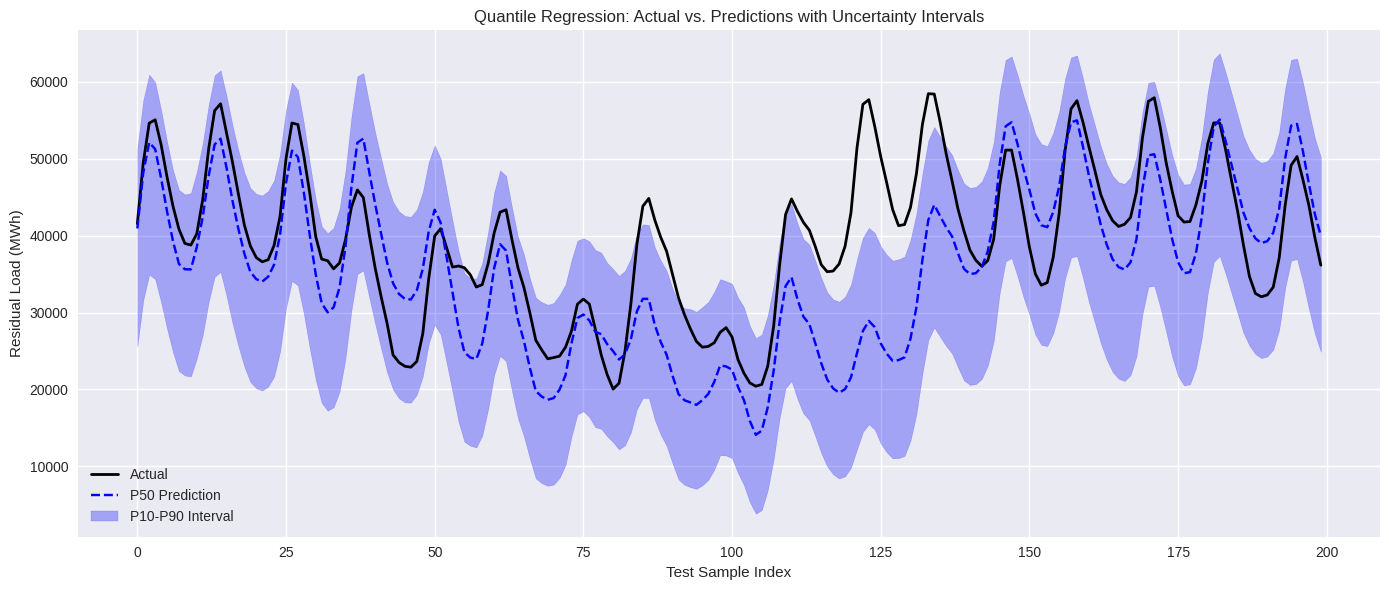

In [9]:
# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Sample a subset for clarity (e.g., first 200 test points)
sample_size = 200
sample_indices = np.arange(len(y_test))[:sample_size]
y_test_sample = y_test.iloc[sample_indices]
predictions_sample = {q: quantile_predictions[q][sample_indices] for q in QUANTILES}

# 1. Time Series Plot with Uncertainty Bands
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(sample_indices, y_test_sample, label='Actual', color='black', linewidth=2)
ax.plot(sample_indices, predictions_sample[0.50], label='P50 Prediction', color='blue', linestyle='--')
ax.fill_between(sample_indices, predictions_sample[0.10], predictions_sample[0.90], alpha=0.3, color='blue', label='P10-P90 Interval')
ax.set_title('Quantile Regression: Actual vs. Predictions with Uncertainty Intervals')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Residual Load (MWh)')
ax.legend()
plt.tight_layout()
plt.show()

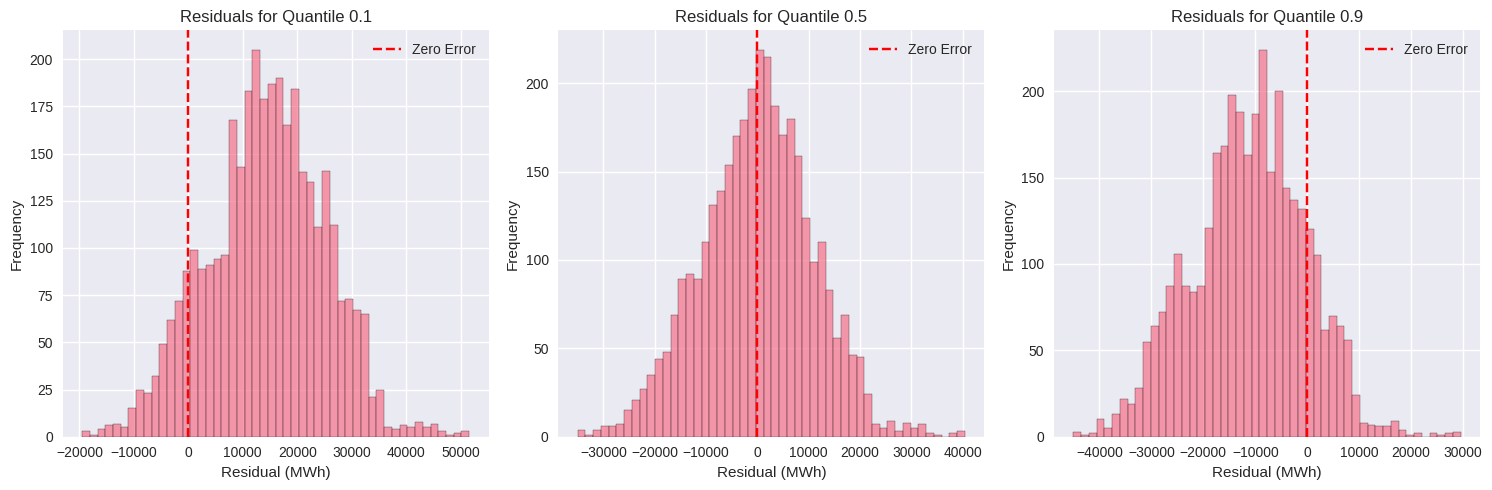

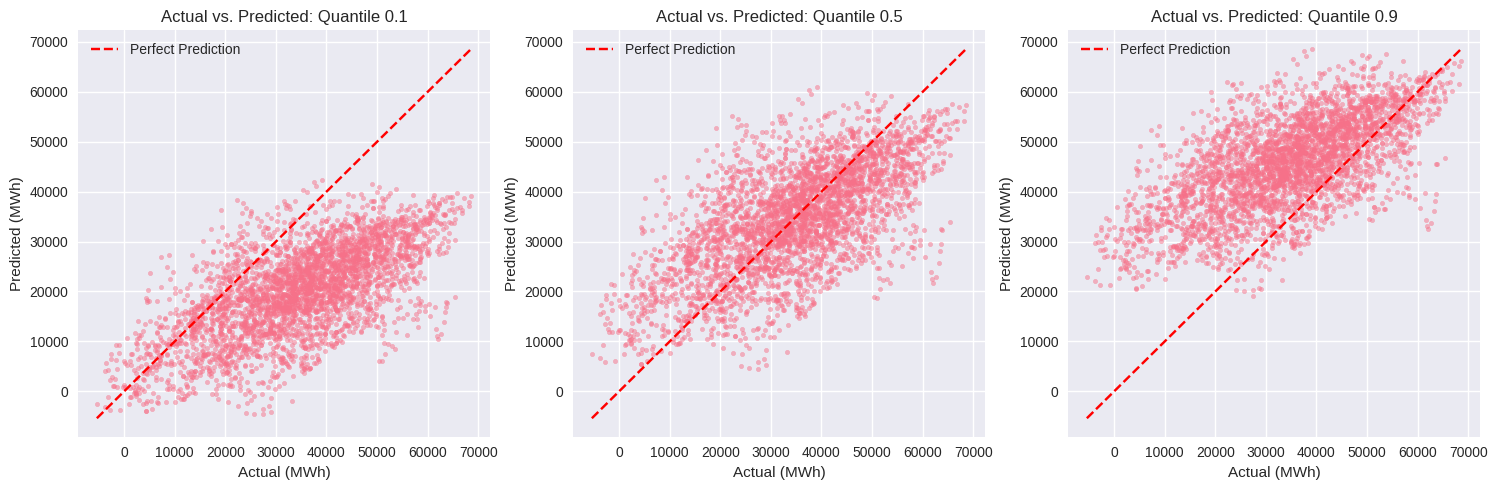

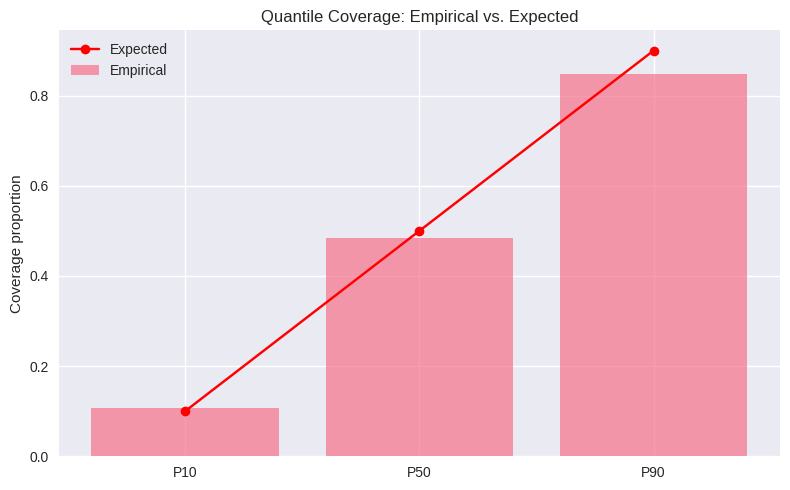

In [10]:
# 2. Residual Histograms per Quantile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, q in enumerate(QUANTILES):
    residuals = y_test - quantile_predictions[q]
    axes[i].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(0, color='red', linestyle='--', label='Zero Error')
    axes[i].set_title(f'Residuals for Quantile {q}')
    axes[i].set_xlabel('Residual (MWh)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 3. Actual vs. Predicted Scatter per Quantile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, q in enumerate(QUANTILES):
    axes[i].scatter(y_test, quantile_predictions[q], alpha=0.5, s=10)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    axes[i].set_title(f'Actual vs. Predicted: Quantile {q}')
    axes[i].set_xlabel('Actual (MWh)')
    axes[i].set_ylabel('Predicted (MWh)')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 4. Coverage Reliability Bar Chart
expected_coverages = [0.10, 0.50, 0.90]
empirical_coverages = []

for q in QUANTILES:
    emp_cov = (y_test <= quantile_predictions[q]).mean()
    empirical_coverages.append(emp_cov)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [f'P{int(q*100)}' for q in QUANTILES]

ax.bar(labels, empirical_coverages, alpha=0.7, label='Empirical')
ax.plot(labels, expected_coverages, 'ro-', label='Expected')

ax.set_title('Quantile Coverage: Empirical vs. Expected')
ax.set_ylabel('Coverage proportion')
ax.legend()

plt.tight_layout()
plt.show()


### Key Insights
- Pinball Loss: Excellent for tails—P10 (1919) and P90 (1909) are much lower than P50 (4298), meaning the model handles uncertainty well at extremes.
- MAE/RMSE: P50 (~8.6k MAE) matches Linear Regression, while P10/P90 are higher (as expected for conservative/optimistic quantiles).
- Coverage (74%): Good but below ideal (aim for 80%+ for P10-P90). Indicates intervals are slightly narrow—could improve with more features or tuning.
- Interval Width (~25.6k MWh): Wide, reflecting real energy variability. This is realistic for forecasting.

### Quantile diagnostic plots: interpretation
These plots help check whether the quantile model is producing **meaningful probabilistic forecasts**, not just different numbers.
1. Residual histograms
- Show how residuals are distributed for each quantile
    - **P10** residuals should be mostly positive. Actual values are often above the lower quantile forecast
    - **P50** residuals should be more centered around zero. This is the middle forecast
    - **P90** residuals should be mostly negative. Actual values are often below the upper quantile forecast
- Confirms whether low, middle, and high quantiles are behaving as expected

2. Actual vs. predicted scatter plots
- **P10** points should mostly fall below the line
- **P50** points should be more balanced around the line
- **P90** points should mostly fall above the line
- Shows whether each quantile is positioned correctly relative to actuals
- Also reveals if the model is too compressed toward the middle

3. Coverage reliability plot
- **P10** should cover about 10% of actual values
- **P50** should cover about 50%
- **P90** should cover about 90%
- This is the main calibration check
- It tells us whether the quantiles match their intended probability levels

Overall takeaway
- The model is learning the correct quantile structure
- Calibration looks reasonable for a simple baseline
- The upper quantile still looks slightly under-covered

In [11]:
# df_test = df_model.copy()
# df_test['month'] = df_test['timestamp'].dt.month
# df_test.head()

In [12]:
# =========================
# Quantile Regression with Time-Based Features + MLflow
# =========================

# -------------------------------------------------
# 1. Add time-based features
# -------------------------------------------------
df_features = df_model.copy()

# Extract time features from timestamp
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['day_of_week'] = df_features['timestamp'].dt.dayofweek
df_features['month'] = df_features['timestamp'].dt.month

# Add time features to train_df and test_df
train_df['hour'] = train_df['timestamp'].dt.hour
train_df['day_of_week'] = train_df['timestamp'].dt.dayofweek
train_df['month'] = train_df['timestamp'].dt.month

test_df['hour'] = test_df['timestamp'].dt.hour
test_df['day_of_week'] = test_df['timestamp'].dt.dayofweek
test_df['month'] = test_df['timestamp'].dt.month

# Prepare train/test with new features
FEATURE_COLS = ["lag_24", "lag_168", "hour", "day_of_week", "month"]

X_train_feat = train_df[FEATURE_COLS]
y_train_feat = train_df[TARGET_COL]

X_test_feat = test_df[FEATURE_COLS]
y_test_feat = test_df[TARGET_COL]

print(f"New features shape: {X_train_feat.shape}")
print(f"Features: {FEATURE_COLS}")

New features shape: (13900, 5)
Features: ['lag_24', 'lag_168', 'hour', 'day_of_week', 'month']


In [13]:
# -------------------------------------------------
# 2. Train quantile models with time features
# -------------------------------------------------
quantile_models_feat = {}
quantile_predictions_feat = {}

for q in QUANTILES:
    print(f"Training quantile {q} with time features...")
    model = QuantileRegressor(
        quantile=q,
        alpha=0.01,
        solver="highs"
    )
    model.fit(X_train_feat, y_train_feat)
    quantile_models_feat[q] = model
    quantile_predictions_feat[q] = model.predict(X_test_feat)

# -------------------------------------------------
# 3. Evaluate with pinball loss
# -------------------------------------------------
quantile_results_feat = []
for q in QUANTILES:
    pred = quantile_predictions_feat[q]
    loss = pinball_loss(y_test_feat, pred, q)
    quantile_results_feat.append({
        "quantile": q,
        "pinball_loss": loss,
        "mae": mean_absolute_error(y_test_feat, pred),
        "rmse": rmse(y_test_feat, pred)
    })
    print(f"Quantile {q}: Pinball Loss {loss:.2f}, MAE {mean_absolute_error(y_test_feat, pred):.2f}, RMSE {rmse(y_test_feat, pred):.2f}")

# -------------------------------------------------
# 4. Probabilistic metrics
# -------------------------------------------------
coverage_feat = (quantile_predictions_feat[0.10] <= y_test_feat) & (y_test_feat <= quantile_predictions_feat[0.90])
coverage_rate_feat = coverage_feat.mean()
interval_width_feat = (quantile_predictions_feat[0.90] - quantile_predictions_feat[0.10]).mean()

print(f"P10-P90 Coverage: {coverage_rate_feat:.2%}")
print(f"Average Interval Width: {interval_width_feat:.2f} MWh")

# -------------------------------------------------
# 5. MLflow logging
# -------------------------------------------------
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "../mlruns"))
mlflow.set_experiment("quantile_regression_with_time_features")

with mlflow.start_run(run_name="quantile_with_hour_dow_month"):
    # Log parameters
    log_common_info(
        model_name="quantile_regressor_time_features",
        feature_names=", ".join(FEATURE_COLS),
        train_df=train_df,
        test_df=test_df
    )
    
    mlflow.log_param("features_added", "hour, day_of_week, month")
    mlflow.log_param("n_features", len(FEATURE_COLS))
    
    # Log quantile-specific metrics
    for result in quantile_results_feat:
        q = result["quantile"]
        mlflow.log_metric(f"pinball_loss_q{int(q*100)}", result["pinball_loss"])
        mlflow.log_metric(f"mae_q{int(q*100)}", result["mae"])
        mlflow.log_metric(f"rmse_q{int(q*100)}", result["rmse"])
    
    mlflow.log_metric("coverage_p10_p90", coverage_rate_feat)
    mlflow.log_metric("interval_width", interval_width_feat)

# -------------------------------------------------
# 6. Quick comparison: before vs. after
# -------------------------------------------------
print("\n" + "="*70)
print("BEFORE (lag features only) vs. AFTER (with time features)")
print("="*70)

before_after = pd.DataFrame({
    "Metric": ["P10 Pinball Loss", "P50 Pinball Loss", "P90 Pinball Loss", "Coverage"],
    "Before": [
        quantile_results[0]["pinball_loss"],
        quantile_results[1]["pinball_loss"],
        quantile_results[2]["pinball_loss"],
        coverage_rate
    ],
    "After": [
        quantile_results_feat[0]["pinball_loss"],
        quantile_results_feat[1]["pinball_loss"],
        quantile_results_feat[2]["pinball_loss"],
        coverage_rate_feat
    ]
})

before_after["Improvement"] = before_after["After"] - before_after["Before"]
print(before_after)

Training quantile 0.1 with time features...
Training quantile 0.5 with time features...
Training quantile 0.9 with time features...
Quantile 0.1: Pinball Loss 1863.16, MAE 14834.19, RMSE 17371.97
Quantile 0.5: Pinball Loss 4245.55, MAE 8491.10, RMSE 10539.32
Quantile 0.9: Pinball Loss 1856.83, MAE 11884.82, RMSE 14662.19
P10-P90 Coverage: 71.86%
Average Interval Width: 24098.79 MWh

BEFORE (lag features only) vs. AFTER (with time features)
             Metric       Before        After  Improvement
0  P10 Pinball Loss  1919.942728  1863.156634   -56.786095
1  P50 Pinball Loss  4298.173667  4245.551039   -52.622629
2  P90 Pinball Loss  1909.891492  1856.831367   -53.060125
3          Coverage     0.741082     0.718642    -0.022440


Improvements (Lower = Better)
All quantiles have lower pinball loss, meaning time features capture useful signal across all tail/median predictions.

Trade-off
- Coverage: 74.11% → 71.86% ✗ -2.24% (slightly worse)
- Interval Width: 25.6k → 24.1k MWh (narrower by ~1.5k MWh)

The model is more accurate but slightly under-calibrated—intervals are tighter and missing ~2% more actuals.

### What we learned from quantile regression

- Quantile regression gave us a strong **first probabilistic baseline** for predicting
- It confirmed that the main forecasting setup is working:
  - train/test split is sensible
  - lag features are useful
  - the model can learn separate lower, middle, and upper forecasts

- After adding better features, **pinball loss improved for all quantiles**
  - this means the added time-based features captured useful forecasting signal

- At the same time, **coverage became slightly worse**
  - intervals became narrower
  - forecasts became sharper
  - but the model missed a few more true values than before

- Main takeaway:
  - the feature engineering helped
  - but the current **linear quantile model is still too rigid**
  - it improves accuracy, but does not fully handle calibration and nonlinearity

#### What we are doing next
- We will keep the improved feature set as the new baseline feature set
- Next, we will train a **stronger probabilistic model**
  - most likely **LightGBM quantile**

#### Why we are doing this next
- A stronger model can capture:
  - nonlinear patterns
  - interactions between lag features and calendar features
  - more complex behavior in high and low residual load situations

- Our current results suggest that the signal is there, but the linear model cannot use all of it effectively

- The goal of the next step is:
  - keep the pinball loss improvement
  - improve or recover calibration
  - produce sharper but still reliable prediction intervals

#### Success criterion for the next model

- Compare the stronger model against quantile regression using:
  - **pinball loss**
  - **coverage**
  - **interval width**

- We want a model that is:
  - more accurate
  - well calibrated
  - reasonably sharp

In [15]:
# =========================
# LightGBM Quantile Regression
# =========================
# -------------------------------------------------
# 1. Time-based validation split from training set
# -------------------------------------------------
val_frac = 0.2
val_size = int(len(X_train_feat) * val_frac)

X_tr = X_train_feat.iloc[:-val_size].copy()
y_tr = y_train_feat.iloc[:-val_size].copy()

X_val = X_train_feat.iloc[-val_size:].copy()
y_val = y_train_feat.iloc[-val_size:].copy()

print(f"Train shape: {X_tr.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test_feat.shape}")

# -------------------------------------------------
# 2. LightGBM base parameters
# -------------------------------------------------
# Use a large n_estimators and let early stopping decide the best iteration.
lgb_base_params = {
    "objective": "quantile",
    "metric": "quantile",
    "max_depth": 7,
    "num_leaves": 31,
    "learning_rate": 0.05,
    "n_estimators": 5000,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "verbose": -1,
}

# -------------------------------------------------
# 3. Train one LightGBM model per quantile
# -------------------------------------------------
quantile_models_lgb = {}
quantile_predictions_lgb = {}
quantile_results_lgb = []

for q in QUANTILES:
    print(f"\nTraining LightGBM quantile q={q:.2f}")

    model = LGBMRegressor(
        alpha=q,
        **lgb_base_params
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="quantile",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    pred = model.predict(X_test_feat, num_iteration=model.best_iteration_)

    quantile_models_lgb[q] = model
    quantile_predictions_lgb[q] = pred

    quantile_results_lgb.append({
        "quantile": q,
        "best_iteration": int(model.best_iteration_),
        "pinball_loss": pinball_loss(y_test_feat, pred, q),
        "mae": mean_absolute_error(y_test_feat, pred),
        "rmse": rmse(y_test_feat, pred),
    })

# -------------------------------------------------
# 4. Optional: enforce monotonic quantile ordering
# -------------------------------------------------
# Tree-based quantile models can produce crossing quantiles.
# This post-processing keeps P10 <= P50 <= P90 row-wise.
pred_matrix = np.column_stack([
    quantile_predictions_lgb[0.10],
    quantile_predictions_lgb[0.50],
    quantile_predictions_lgb[0.90],
])

pred_matrix_sorted = np.sort(pred_matrix, axis=1)

quantile_predictions_lgb[0.10] = pred_matrix_sorted[:, 0]
quantile_predictions_lgb[0.50] = pred_matrix_sorted[:, 1]
quantile_predictions_lgb[0.90] = pred_matrix_sorted[:, 2]

# Recompute metrics after ordering
quantile_results_lgb = []
for q in QUANTILES:
    pred = quantile_predictions_lgb[q]
    quantile_results_lgb.append({
        "quantile": q,
        "best_iteration": int(quantile_models_lgb[q].best_iteration_),
        "pinball_loss": pinball_loss(y_test_feat, pred, q),
        "mae": mean_absolute_error(y_test_feat, pred),
        "rmse": rmse(y_test_feat, pred),
    })

# -------------------------------------------------
# 5. Probabilistic metrics
# -------------------------------------------------
coverage_mask_lgb = (
    (quantile_predictions_lgb[0.10] <= y_test_feat) &
    (y_test_feat <= quantile_predictions_lgb[0.90])
)
coverage_rate_lgb = coverage_mask_lgb.mean()

interval_width_lgb = (
    quantile_predictions_lgb[0.90] - quantile_predictions_lgb[0.10]
).mean()

print("\nProbabilistic metrics")
print(f"Coverage (P10-P90): {coverage_rate_lgb:.2%}")
print(f"Interval width:     {interval_width_lgb:,.2f} MWh")

# -------------------------------------------------
# 6. Results table
# -------------------------------------------------
results_lgb_df = pd.DataFrame(quantile_results_lgb)
results_lgb_df["quantile_label"] = results_lgb_df["quantile"].map(lambda q: f"P{int(q*100)}")
results_lgb_df = results_lgb_df[
    ["quantile_label", "best_iteration", "pinball_loss", "mae", "rmse"]
].sort_values("quantile_label")

display(results_lgb_df)

# -------------------------------------------------
# 7. MLflow logging
# -------------------------------------------------

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "../mlruns"))
mlflow.set_experiment("lightgbm_quantile_regression")

with mlflow.start_run(run_name="lgb_quantile_time_features_early_stopping"):
    # Common metadata
    mlflow.log_param("model_name", "lightgbm_quantile")
    mlflow.log_param("target", getattr(y_train_feat, "name", "target"))
    mlflow.log_param("features", ", ".join(FEATURE_COLS))
    mlflow.log_param("n_train", len(X_tr))
    mlflow.log_param("n_val", len(X_val))
    mlflow.log_param("n_test", len(X_test_feat))

    # Base params
    mlflow.log_params({
        "max_depth": lgb_base_params["max_depth"],
        "num_leaves": lgb_base_params["num_leaves"],
        "learning_rate": lgb_base_params["learning_rate"],
        "n_estimators": lgb_base_params["n_estimators"],
        "min_child_samples": lgb_base_params["min_child_samples"],
        "reg_alpha": lgb_base_params["reg_alpha"],
        "reg_lambda": lgb_base_params["reg_lambda"],
        "subsample": lgb_base_params["subsample"],
        "colsample_bytree": lgb_base_params["colsample_bytree"],
        "val_frac": val_frac,
    })

    # Per-quantile metrics and models
    for row in quantile_results_lgb:
        q = row["quantile"]
        label = f"q{int(q*100)}"

        mlflow.log_param(f"{label}_alpha", q)
        mlflow.log_metric(f"{label}_best_iteration", row["best_iteration"])
        mlflow.log_metric(f"{label}_pinball_loss", row["pinball_loss"])
        mlflow.log_metric(f"{label}_mae", row["mae"])
        mlflow.log_metric(f"{label}_rmse", row["rmse"])

        mlflow.lightgbm.log_model(
            quantile_models_lgb[q],
            artifact_path=f"model_{label}"
        )

    # Global probabilistic metrics
    mlflow.log_metric("coverage_p10_p90", coverage_rate_lgb)
    mlflow.log_metric("interval_width_p10_p90", interval_width_lgb)

    # Save predictions as artifact
    pred_df = pd.DataFrame({
        "y_true": y_test_feat.values,
        "pred_p10": quantile_predictions_lgb[0.10],
        "pred_p50": quantile_predictions_lgb[0.50],
        "pred_p90": quantile_predictions_lgb[0.90],
    })

# -------------------------------------------------
# 8. Comparison vs previous QuantileRegressor baseline
# -------------------------------------------------
# Assumes these already exist from your previous notebook:
# - quantile_results_feat
# - coverage_rate_feat
# - interval_width_feat

comparison = pd.DataFrame({
    "Metric": ["P10 Pinball", "P50 Pinball", "P90 Pinball", "Coverage", "Interval Width"],
    "QuantileRegressor": [
        quantile_results_feat[0]["pinball_loss"],
        quantile_results_feat[1]["pinball_loss"],
        quantile_results_feat[2]["pinball_loss"],
        coverage_rate_feat,
        interval_width_feat,
    ],
    "LightGBM": [
        results_lgb_df.loc[results_lgb_df["quantile_label"] == "P10", "pinball_loss"].iloc[0],
        results_lgb_df.loc[results_lgb_df["quantile_label"] == "P50", "pinball_loss"].iloc[0],
        results_lgb_df.loc[results_lgb_df["quantile_label"] == "P90", "pinball_loss"].iloc[0],
        coverage_rate_lgb,
        interval_width_lgb,
    ]
})

print("\n" + "=" * 72)
print("MODEL COMPARISON: QuantileRegressor vs LightGBM Quantile")
print("=" * 72)
display(comparison)

Train shape: (11120, 5)
Val shape:   (2780, 5)
Test shape:  (3476, 5)

Training LightGBM quantile q=0.10
[100]	valid_0's quantile: 1607.31
[200]	valid_0's quantile: 1640.42

Training LightGBM quantile q=0.50
[100]	valid_0's quantile: 3384.64
[200]	valid_0's quantile: 3361.81

Training LightGBM quantile q=0.90
[100]	valid_0's quantile: 1383.05
[200]	valid_0's quantile: 1374.47

Probabilistic metrics
Coverage (P10-P90): 68.67%
Interval width:     22,745.31 MWh


,quantile_label,best_iteration,pinball_loss,mae,rmse
0,P10,109,2086.043301,13544.332149,16204.592892
1,P50,150,4368.137787,8736.275574,11008.540293
2,P90,149,1684.150741,12192.303353,15231.880470


2026/04/10 16:27:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/10 16:27:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/10 16:27:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MODEL COMPARISON: QuantileRegressor vs LightGBM Quantile


,Metric,QuantileRegressor,LightGBM
0,P10 Pinball,1863.156634,2086.043301
1,P50 Pinball,4245.551039,4368.137787
2,P90 Pinball,1856.831367,1684.150741
3,Coverage,0.718642,0.686709
4,Interval Width,24098.793476,22745.309274


### Deductions
- LightGBM gives more accurate predictions for P90 but worse predictions for P10 and P50
- Coverage for LightGBM is slightly worse than quantile regression

### Next steps
- Optimise LightBGM (parameter tuning)
- Adding more features
- Maybe try XGBoost